# How to use Control toolbox in Python

In [106]:
import requests as req, os
import importlib.util

URL = "https://raw.githubusercontent.com/mit-acl/16_06_Class/main/"
File = ["basic_material.py","control_materials.py","read_csv_data.py"]

if not os.path.isfile(File[0]):
    print('Basic files not` found - downloading it')
    for dfile in File:
        if not os.path.isfile(dfile):
            print(dfile)
            res = req.get(URL+dfile)
            file = open(dfile, 'w')
            file.write(res.text)
            file.close()

print('Basic file found')
%run basic_material.py

from control.matlab import tf, ss, ss2tf, bode, step, initial, lsim, margin, impulse

Basic file found
Running Python: 3.8.17
Running Sympy: 1.12rc1


In [107]:
# define P as a transfer function
P = tf([0, 4],[1,2,3])
P

TransferFunction(array([4]), array([1, 2, 3]))

In [108]:
# Second approach
s = tf('s')
P = 4/(s**2 + 2*s + 3)
P

TransferFunction(array([4]), array([1, 2, 3]))

In [109]:
# third approach
A = [[0, 1],[-3, -2]]
B = [[0],[1]]
C = [[4, 0],[0, 1]]
D = [[0],[0]]
Pss = ss(A,B,C,D)
Pss

<LinearIOSystem:sys[186]:['u[0]']->['y[0]', 'y[1]']>

In [110]:
# remove weird scaling artifacts
def near_zero(P, Tol = 1e-12):
    P.num[0][0] = [x if abs(x) > Tol else 0.0 for x in P.num[0][0]]
    return P

In [111]:
P = ss2tf(A,B,C[0][:],D[0][:]) # to be consistent with the above
# fix some poor scaling
P = near_zero(P)
P

TransferFunction([4.0], array([   1.000,    2.000,    3.000]))

# Try some plotting

In [112]:
t = np.arange(0,10,0.01)
y,t = impulse(Pss,t)

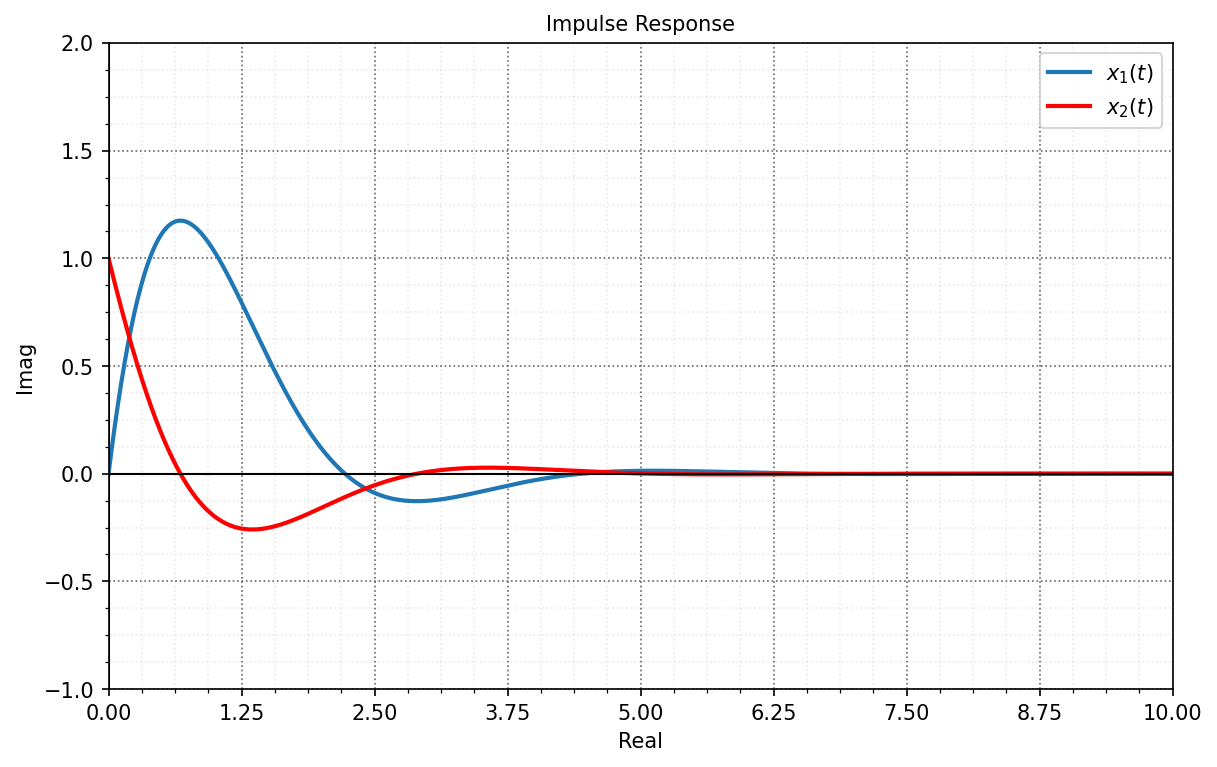

In [113]:
fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150,constrained_layout = True)
plt.plot(t,y[:,0],label='$x_1(t)$')
plt.plot(t,y[:,1],'r',label='$x_2(t)$')
plt.minorticks_on()
plt.xlim(0,10)
plt.ylim(-1,2)
plt.xlabel('Real')
plt.ylabel('Imag')
plt.title('Impulse Response')
nicegrid(ax)
plt.legend()
#plt.show()

In [114]:
ax.yaxis.get_major_locator()

In [115]:
t = np.arange(0,10,0.001)
y,t = step(Pss,t)

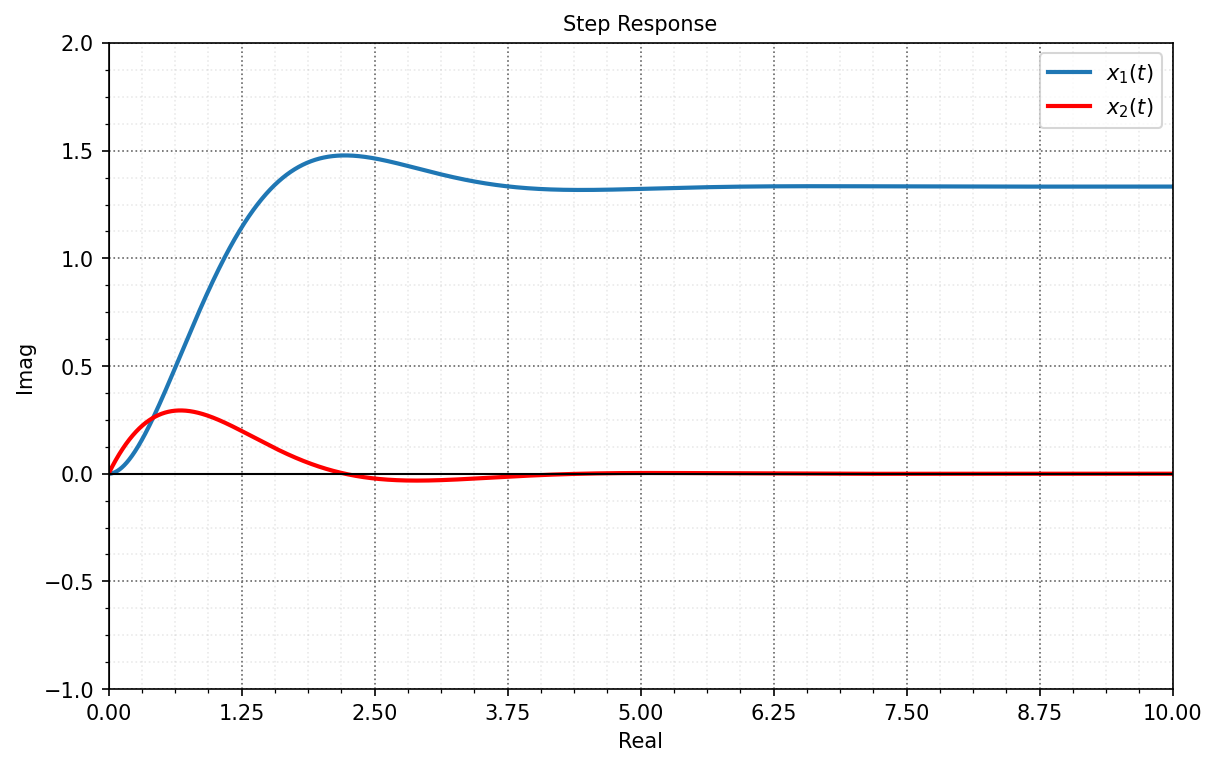

In [116]:
fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150,constrained_layout = True)
plt.plot(t,y[:,0],label='$x_1(t)$')
plt.plot(t,y[:,1],'r',label='$x_2(t)$')

nicegrid(ax)
plt.legend()
plt.xlim(0,10)
plt.ylim(-1,2)
plt.xlabel('Real')
plt.ylabel('Imag')
plt.title('Step Response')
plt.show()


In [117]:
X0 = [0, -1]
y,t = initial(Pss,t,X0)

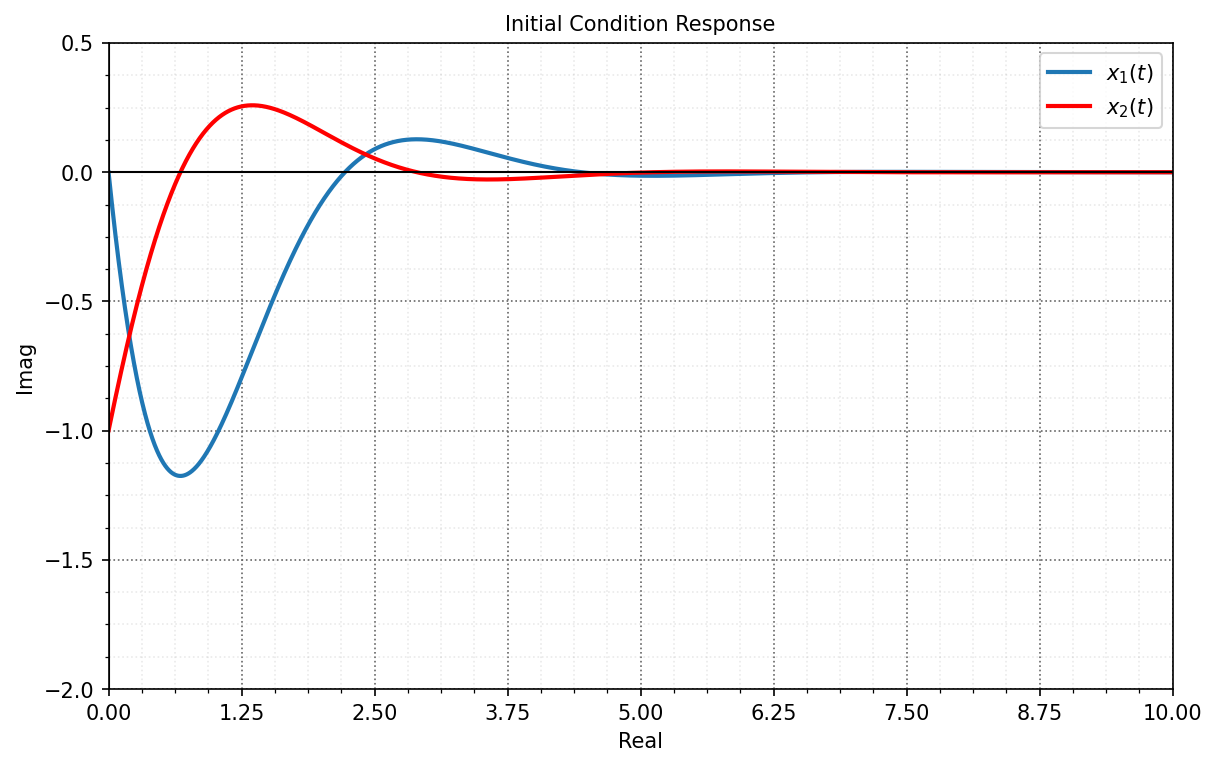

In [118]:
fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150,constrained_layout = True)
plt.plot(t,y[:,0],label='$x_1(t)$')
plt.plot(t,y[:,1],'r',label='$x_2(t)$')

nicegrid(ax)
plt.legend()
plt.xlim(0,10)
plt.ylim(-2,0.5)
plt.xlabel('Real')
plt.ylabel('Imag')
plt.title('Initial Condition Response')
plt.show()

In [119]:
U = np.sin(5*2*np.pi*t)
y,t,xout = lsim(Pss,U,t,X0)

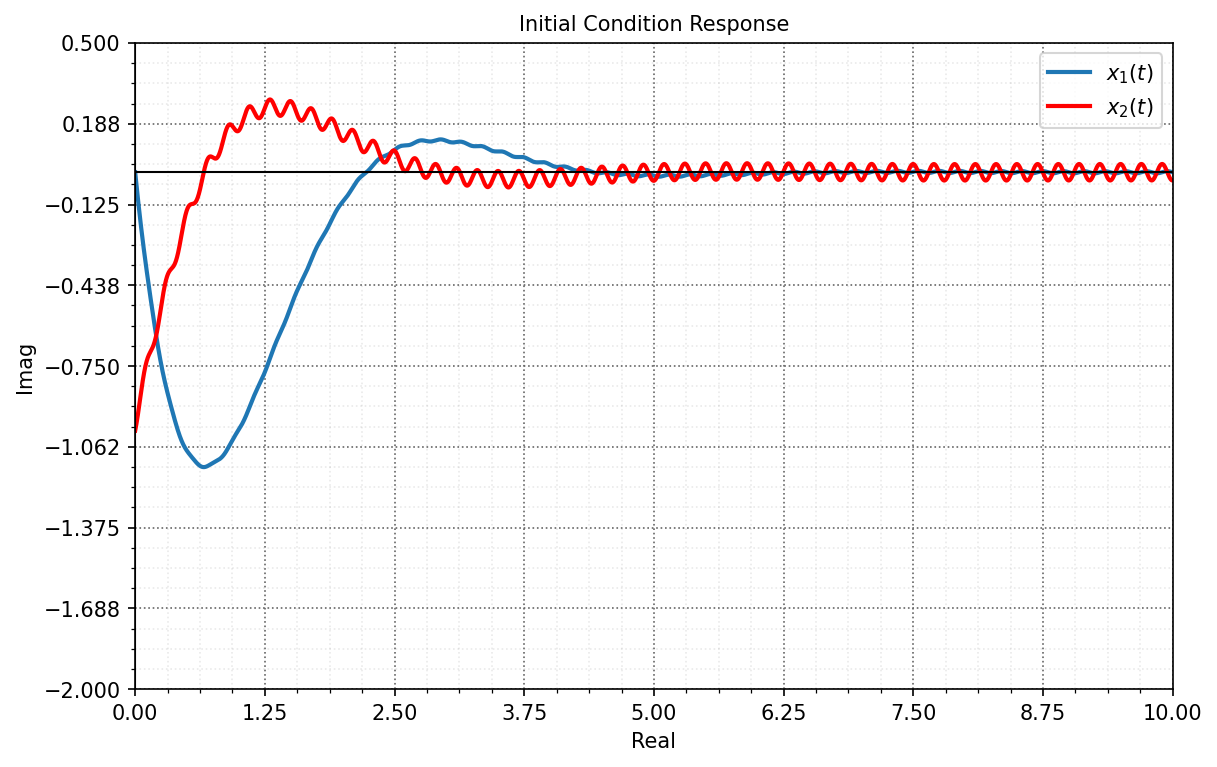

In [77]:
fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150,constrained_layout = True)
plt.plot(t,y[:,0],label='$x_1(t)$')
plt.plot(t,y[:,1],'r',label='$x_2(t)$')

nicegrid(ax)
plt.legend()
plt.xlim(0,10)
plt.ylim(-2,0.5)
plt.xlabel('Real')
plt.ylabel('Imag')
plt.title('Initial Condition Response')
plt.show()


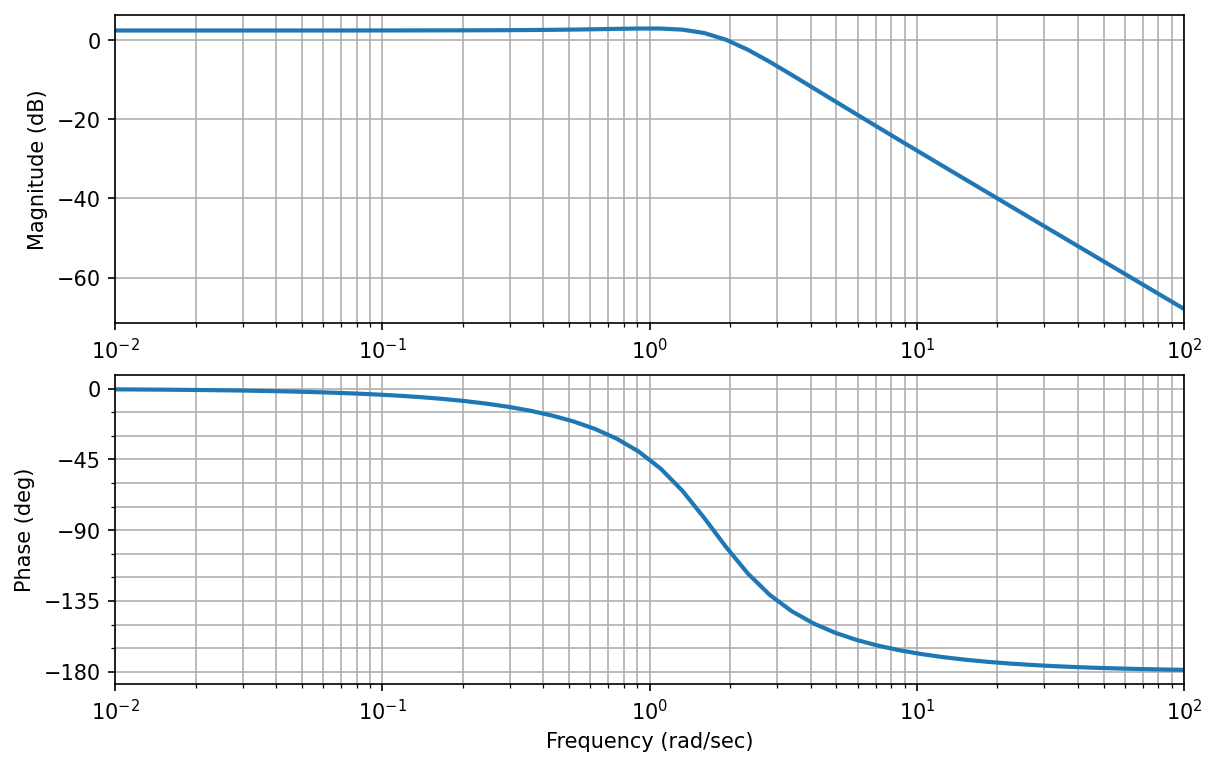

In [70]:
s = tf('s')
P = 4/(s**2 + 2*s + 3)
fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150,constrained_layout = True)
gain, phase, w = bode(P, logspace(-2,2))
plt.xlim(.01,100)
plt.show()

In [71]:
GM, PM, wpc, wgc = margin(P)
print(f'GM = {20*np.log10(GM):2f}')
print(f'PM = {PM:2f}')
print(f'wpc = {wpc:2f}')
print(f'wgc = {wgc:2f}')


GM = inf
PM = 78.047144
wpc = nan
wgc = 1.956637
